***cell 1 - setup stage ***

import y-finance as a tool that pulls stock prices.

represent stocks by their ticker short codes in y-finance.
all stocks in portfolio have equal weighting.

set window for historical data, value of porfolio, number of simulations for monte carlo.

for any given day this model spits out a singular VAR dollar amount. - hence we operate on a 95% confidence level that daily losses will not exceed that amount.

eg. so over a 100-day period, we'd expect roughly 5 trading days where losses
exceed that day's VaR estimate — not exactly 5, but close to it if the
model is well-calibrated.






In [5]:
!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",
    "META", "TSLA", "JPM", "V", "JNJ",
    "WMT", "PG", "XOM", "UNH", "HD",
]

WEIGHTS = np.array([1 / len(TICKERS)] * len(TICKERS))

START_DATE = "2021-01-01"
END_DATE = "2026-01-01"

CONFIDENCE = 0.95
ALPHA = 1 - CONFIDENCE

PORTFOLIO_VALUE = 1_000_000
N_SIMULATIONS = 100_000
LOOKBACK_WINDOW = 252

print("Config loaded.")

Config loaded.


cell 2 - collection of data

present value of 15 stock portfolio as table. - 1 col per stock and each row is 1 trading day.

Daily price movement is expressed as a ratio of today's price to
yesterday's, then converted into a log return. VaR is calculated on
these log returns, not on raw prices — we measure risk based on price movement not on the actual price.

then we convert into 1 portfolio adding each stock return whilst accounting for weight- all the same for the project.

plot acts as a sanity check - wobbly line bouncing around zero.


[*********************100%***********************]  15 of 15 completed


Data range: 2021-01-05 to 2025-12-31
Trading days: 1254


<Axes: title={'center': 'Portfolio daily returns'}, xlabel='Date'>

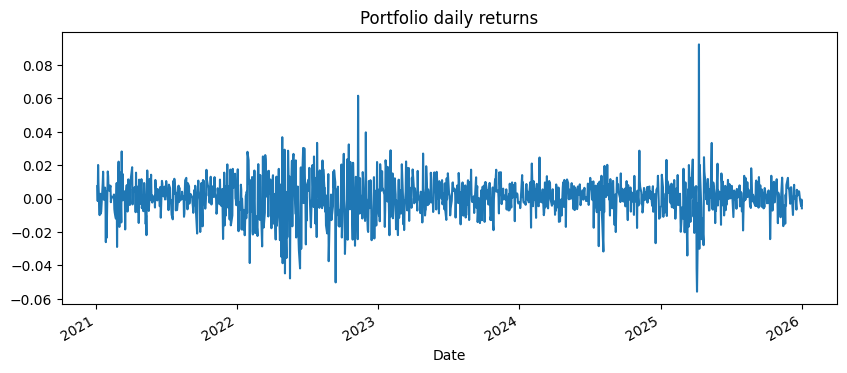

In [6]:
import yfinance as yf

prices = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)["Close"]  #adjusts historical prices for stock splits and dividends.
prices = prices.dropna(how="all").ffill().dropna() #carrying forward missing stocks.

log_returns = np.log(prices / prices.shift(1)).dropna()  #drops all stocks that have a missing day, ie market holiday.
portfolio_returns = log_returns @ WEIGHTS

print(f"Data range: {portfolio_returns.index[0].date()} to {portfolio_returns.index[-1].date()}")
print(f"Trading days: {len(portfolio_returns)}")
portfolio_returns.plot(figsize=(10, 4), title="Portfolio daily returns")

cell 3
to compare the 3 methods, each produces a var estimate on a 95% confidence level.


In [7]:

#historical sorts through every day of porfolio returns and places in order, we find Var value from the 5th percentile value.
def historical_var(returns, alpha=ALPHA):
    return -np.percentile(returns, alpha * 100) #labelling convention to flip signs - negative returns are represented as positive losses.

#parametric- using mean and sd we create a perfect bell curve and thus approximate where the 5th percentile sits.
def parametric_var(returns, alpha=ALPHA):
    mu = returns.mean()
    sigma = returns.std()
    z = norm.ppf(alpha)
    return -(mu + z * sigma)

#create a covariance matrix where we account for relationships between every stock in portfolio.
#we then generate 100,000 fake days and return fake portfolio returns - sorted to then find 5th percentile.
def monte_carlo_var(log_returns, weights, alpha=ALPHA, n_sims=N_SIMULATIONS):
    mu = log_returns.mean().values
    cov = log_returns.cov().values
    simulated_asset_returns = np.random.multivariate_normal(mu, cov, size=n_sims)
    simulated_portfolio_returns = simulated_asset_returns @ weights
    return -np.percentile(simulated_portfolio_returns, alpha * 100)

hist_var = historical_var(portfolio_returns)
param_var = parametric_var(portfolio_returns)
mc_var = monte_carlo_var(log_returns, WEIGHTS)

print("=== 95% 1-Day VaR Estimates (full sample) ===")
for name, v in [("Historical", hist_var), ("Parametric", param_var), ("Monte Carlo", mc_var)]:
    print(f"{name:>12}: {v*100:6.2f}%   (${v * PORTFOLIO_VALUE:,.0f} on a ${PORTFOLIO_VALUE:,} book)")

=== 95% 1-Day VaR Estimates (full sample) ===
  Historical:   1.86%   ($18,626 on a $1,000,000 book)
  Parametric:   1.84%   ($18,364 on a $1,000,000 book)
 Monte Carlo:   1.84%   ($18,386 on a $1,000,000 book)


cell 4 - backtesting loop that measures validity of model.

For day 301, we pretend day 301 doesn't exist yet. We use only the
252 days before it to compute a VaR estimate — a prediction of what
day 301's loss threshold should be. Then we "reveal" day 301's actual
return and check: did the real loss exceed the predicted VaR? Repeat
this for every day in the dataset, and count how often the breach
happened.

we start at day 253. -252 is the number of trading days in a year.


In [8]:
def backtest_var(portfolio_returns, log_returns, weights, method, window=LOOKBACK_WINDOW, alpha=ALPHA):
    violations = []
    var_series = []
    dates = portfolio_returns.index[window:]

    for i in range(window, len(portfolio_returns)):
        hist_window = portfolio_returns.iloc[i - window:i]
        log_window = log_returns.iloc[i - window:i]

        if method == "historical":
            var_est = historical_var(hist_window, alpha)
        elif method == "parametric":
            var_est = parametric_var(hist_window, alpha)
        elif method == "monte_carlo":
            var_est = monte_carlo_var(log_window, weights, alpha, n_sims=5000)
        else:
            raise ValueError("Unknown method")

        actual_return = portfolio_returns.iloc[i]
        breach = actual_return < -var_est

        var_series.append(var_est)
        violations.append(breach)

    violations = np.array(violations)
    violation_rate = violations.mean()
    return pd.Series(var_series, index=dates), violation_rate

results = {}
for method in ["historical", "parametric", "monte_carlo"]:
    var_series, viol_rate = backtest_var(portfolio_returns, log_returns, WEIGHTS, method)
    results[method] = (var_series, viol_rate)
    print(f"{method:>12} backtest violation rate: {viol_rate*100:.2f}%  "
          f"(target ~{ALPHA*100:.0f}%, {len(var_series)} obs)")

  historical backtest violation rate: 5.59%  (target ~5%, 1002 obs)
  parametric backtest violation rate: 5.89%  (target ~5%, 1002 obs)
 monte_carlo backtest violation rate: 5.79%  (target ~5%, 1002 obs)


cell 5 - visual representation of breaches found in cell 4.
each time a grey line dips below a VAR colour line its counted as a breach.

we can visually view where the breach clusters exist which the violation rates found above wont tell us.

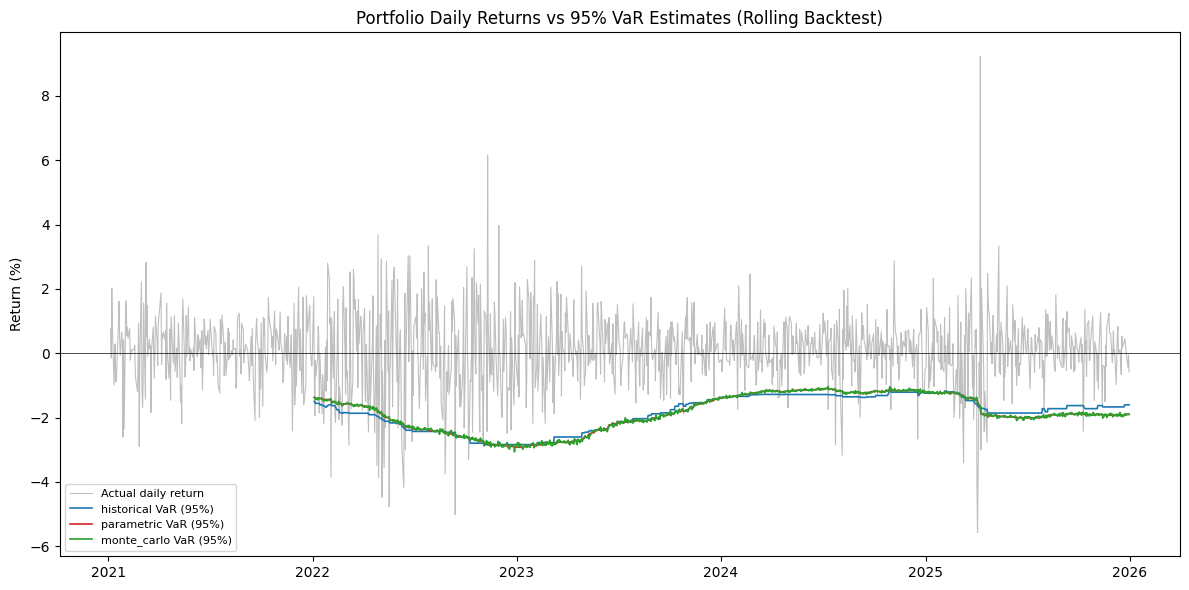

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(portfolio_returns.index, portfolio_returns.values * 100,
        label="Actual daily return", color="grey", alpha=0.5, linewidth=0.8)

for method, color in [("historical", "tab:blue"), ("parametric", "tab:red"), ("monte_carlo", "tab:green")]:
    var_series, _ = results[method]
    ax.plot(var_series.index, -var_series.values * 100,
            label=f"{method} VaR (95%)", color=color, linewidth=1.2)

ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Portfolio Daily Returns vs 95% VaR Estimates (Rolling Backtest)")
ax.set_ylabel("Return (%)")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig("var_backtest.png", dpi=150)
plt.show()